## Rotational Broadening: Convolution vs Direct Integration

This notebook compares two different approaches for rotational broadening:

1. **Convolution Method**: Uses the Gray profile kernel for fast convolution-based broadening
2. **Direct Integration Method**: Uses the Carvalho & Johns-Krull (2023) approach with direct disk integration

We'll examine the differences in results, performance, and when to use each method.


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import time

from broadpy import RotationalBroadening
from broadpy.utils import load_example_data

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
# Load PHOENIX model (R~1e6)
wave, flux = load_example_data()

print(f"Wavelength range: {wave.min():.2f} - {wave.max():.2f} nm")
print(f"Spectral resolution: {len(wave)} points")
print(f"Mean wavelength spacing: {np.mean(np.diff(wave)):.6f} nm")


Wavelength range: 2320.00 - 2330.00 nm
Spectral resolution: 10001 points
Mean wavelength spacing: 0.001000 nm


In [53]:
# Set up rotational broadening parameters
vsini = 5.0  # km/s - moderate rotation
eps = 0.6     # limb darkening coefficient

# Create RotationalBroadening instance
RB = RotationalBroadening(wave, flux)

print(f"Rotational velocity: {vsini} km/s")
print(f"Limb darkening coefficient: {eps}")
print(f"Maximum Doppler shift: {vsini * np.mean(wave) / 2.998e5:.4f} nm")


Rotational velocity: 5.0 km/s
Limb darkening coefficient: 0.6
Maximum Doppler shift: 0.0388 nm


In [54]:
# Apply convolution-based rotational broadening
print("Applying convolution method...")
start_time = time.time()
flux_conv = RB(vsini=vsini, epsilon=eps)
conv_time = time.time() - start_time

print(f"Convolution method completed in {conv_time*1000:.2f} ms")


Applying convolution method...
Convolution method completed in 0.65 ms


In [55]:
# Apply direct integration method with different resolution settings
print("Applying direct integration method...")

# Test different integration resolutions
nr_values = [10, 30, 50, 80]
ntheta_values = [30, 50, 80]

flux_direct = {}
direct_times = {}

for nr in nr_values:
    for ntheta in ntheta_values:
        print(f"  Testing nr={nr}, ntheta={ntheta}...")
        start_time = time.time()
        flux_direct[f"nr{nr}_nt{ntheta}"] = RB.direct_integration_carvalho(
            vsini=vsini, eps=eps, nr=nr, ntheta=ntheta
        )
        direct_times[f"nr{nr}_nt{ntheta}"] = time.time() - start_time
        print(f"    Completed in {direct_times[f'nr{nr}_nt{ntheta}']*1000:.2f} ms")

# Use the highest resolution for main comparison
flux_direct_main = flux_direct[f"nr{nr_values[-1]}_nt{ntheta_values[-1]}"]
direct_time_main = direct_times[f"nr{nr_values[-1]}_nt{ntheta_values[-1]}"]


Applying direct integration method...
  Testing nr=10, ntheta=30...
    Completed in 9.33 ms
  Testing nr=10, ntheta=50...
    Completed in 13.31 ms
  Testing nr=10, ntheta=80...
    Completed in 20.74 ms
  Testing nr=30, ntheta=30...
    Completed in 22.25 ms
  Testing nr=30, ntheta=50...
    Completed in 37.38 ms
  Testing nr=30, ntheta=80...
    Completed in 66.00 ms
  Testing nr=50, ntheta=30...
    Completed in 39.47 ms
  Testing nr=50, ntheta=50...
    Completed in 63.03 ms
  Testing nr=50, ntheta=80...
    Completed in 105.68 ms
  Testing nr=80, ntheta=30...
    Completed in 64.80 ms
  Testing nr=80, ntheta=50...
    Completed in 108.33 ms
  Testing nr=80, ntheta=80...
    Completed in 184.64 ms


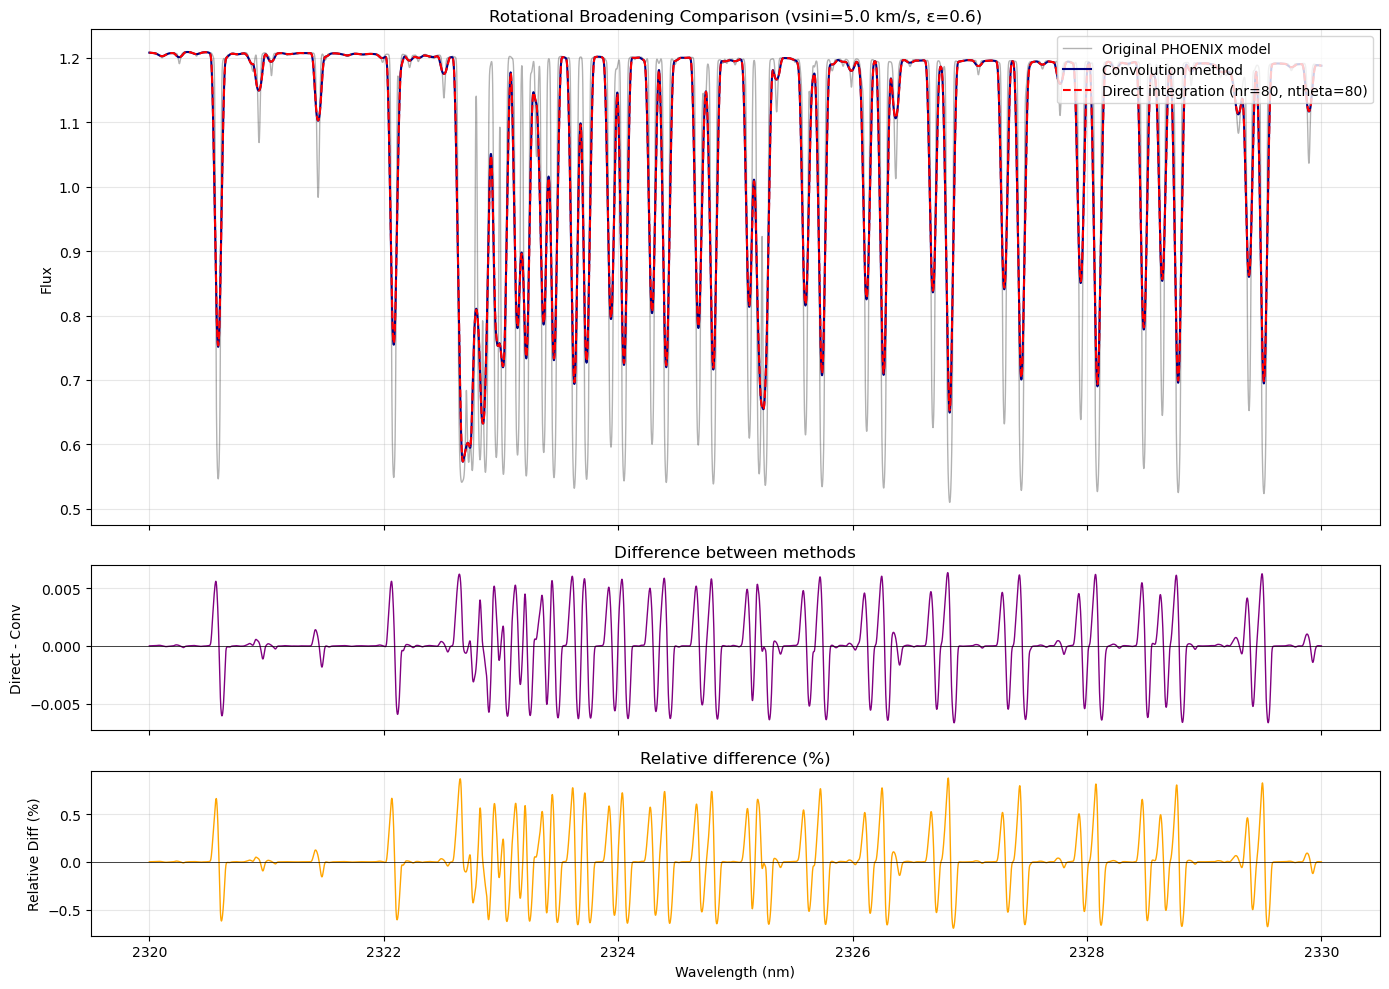


Method Comparison Statistics:
Convolution method time: 0.65 ms
Direct integration time: 184.64 ms
Speed ratio (conv/direct): 0.0x
Mean absolute difference: 1.53e-03
Max absolute difference: 6.65e-03
RMS difference: 2.54e-03
Mean relative difference: 0.164%


In [56]:
# Create comparison plots
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, 
                        gridspec_kw={'height_ratios': [3, 1, 1]})

# Main spectrum comparison
axes[0].plot(wave, flux, label='Original PHOENIX model', alpha=0.3, color='black', linewidth=1)
axes[0].plot(wave, flux_conv, label='Convolution method', color='navy', linewidth=1.5)
axes[0].plot(wave, flux_direct_main, label=f'Direct integration (nr={nr_values[-1]}, ntheta={ntheta_values[-1]})', 
             color='red', linewidth=1.5, linestyle='--')

axes[0].set_ylabel('Flux')
axes[0].legend(loc='upper right')
axes[0].set_title(f'Rotational Broadening Comparison (vsini={vsini} km/s, ε={eps})')
axes[0].grid(True, alpha=0.3)

# Residuals: Direct integration - Convolution
residuals = flux_direct_main - flux_conv
axes[1].plot(wave, residuals, color='purple', linewidth=1)
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Direct - Conv')
axes[1].set_title('Difference between methods')
axes[1].grid(True, alpha=0.3)

# Show relative difference
relative_diff = residuals / flux_conv * 100
axes[2].plot(wave, relative_diff, color='orange', linewidth=1)
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_ylabel('Relative Diff (%)')
axes[2].set_xlabel('Wavelength (nm)')
axes[2].set_title('Relative difference (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nMethod Comparison Statistics:")
print(f"Convolution method time: {conv_time*1000:.2f} ms")
print(f"Direct integration time: {direct_time_main*1000:.2f} ms")
print(f"Speed ratio (conv/direct): {conv_time/direct_time_main:.1f}x")
print(f"Mean absolute difference: {np.mean(np.abs(residuals)):.2e}")
print(f"Max absolute difference: {np.max(np.abs(residuals)):.2e}")
print(f"RMS difference: {np.sqrt(np.mean(residuals**2)):.2e}")
print(f"Mean relative difference: {np.mean(np.abs(relative_diff)):.3f}%")


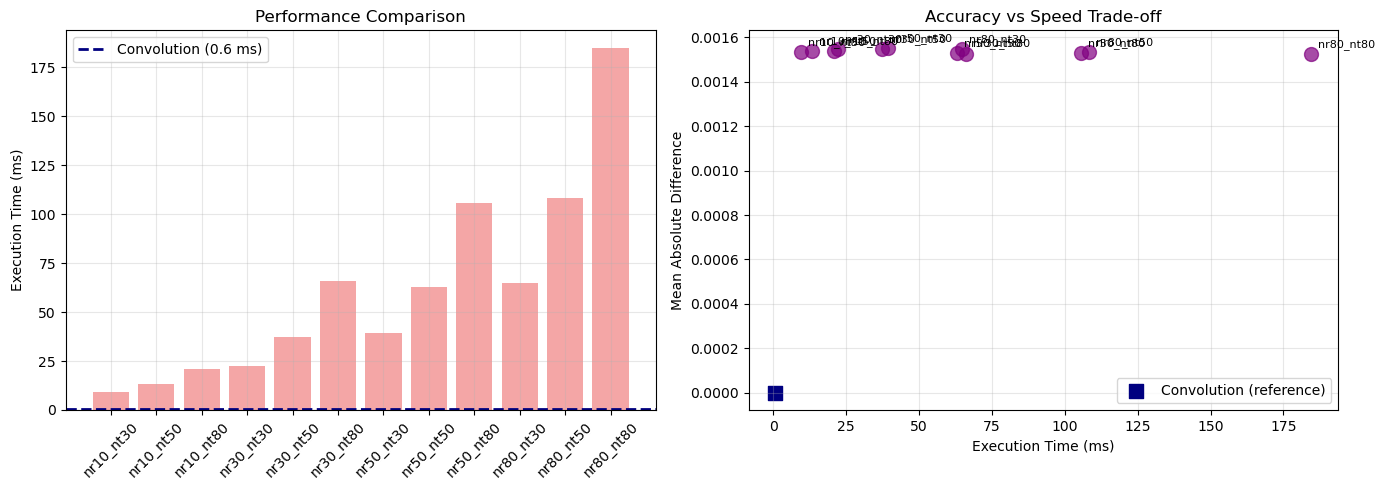


Performance Summary:
Resolution      Time (ms)    Accuracy     Speedup   
-------------------------------------------------------
nr10_nt30       9.3          1.53e-03     0.1       x
nr10_nt50       13.3         1.54e-03     0.0       x
nr10_nt80       20.7         1.54e-03     0.0       x
nr30_nt30       22.3         1.55e-03     0.0       x
nr30_nt50       37.4         1.55e-03     0.0       x
nr30_nt80       66.0         1.53e-03     0.0       x
nr50_nt30       39.5         1.55e-03     0.0       x
nr50_nt50       63.0         1.53e-03     0.0       x
nr50_nt80       105.7        1.53e-03     0.0       x
nr80_nt30       64.8         1.55e-03     0.0       x
nr80_nt50       108.3        1.53e-03     0.0       x
nr80_nt80       184.6        1.53e-03     0.0       x
Convolution     0.6          0.00e+00     1.0       x


In [57]:
# Performance comparison with different integration resolutions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot execution times
resolutions = list(direct_times.keys())
times = list(direct_times.values())
times_ms = [t * 1000 for t in times]

ax1.bar(range(len(resolutions)), times_ms, color='lightcoral', alpha=0.7)
ax1.axhline(conv_time * 1000, color='navy', linestyle='--', linewidth=2, 
           label=f'Convolution ({conv_time*1000:.1f} ms)')
ax1.set_xticks(range(len(resolutions)))
ax1.set_xticklabels(resolutions, rotation=45)
ax1.set_ylabel('Execution Time (ms)')
ax1.set_title('Performance Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy vs speed trade-off
accuracy_metrics = []
for key in resolutions:
    diff = np.mean(np.abs(flux_direct[key] - flux_conv))
    accuracy_metrics.append(diff)

ax2.scatter(times_ms, accuracy_metrics, s=100, alpha=0.7, color='purple')
ax2.scatter(conv_time * 1000, 0, s=100, color='navy', marker='s', 
           label='Convolution (reference)')
ax2.set_xlabel('Execution Time (ms)')
ax2.set_ylabel('Mean Absolute Difference')
ax2.set_title('Accuracy vs Speed Trade-off')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add labels for each point
for i, key in enumerate(resolutions):
    ax2.annotate(key, (times_ms[i], accuracy_metrics[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nPerformance Summary:")
print(f"{'Resolution':<15} {'Time (ms)':<12} {'Accuracy':<12} {'Speedup':<10}")
print("-" * 55)
for key in resolutions:
    speedup = conv_time / direct_times[key]
    accuracy = np.mean(np.abs(flux_direct[key] - flux_conv))
    print(f"{key:<15} {direct_times[key]*1000:<12.1f} {accuracy:<12.2e} {speedup:<10.1f}x")
print(f"{'Convolution':<15} {conv_time*1000:<12.1f} {'0.00e+00':<12} {'1.0':<10}x")


Testing with different vsini values...
vsini (km/s) Conv Time (ms)  Direct Time (ms) Difference  
------------------------------------------------------------
5            0.6             51.6             1.53e-03    
15           1.2             51.2             2.36e-04    
25           1.7             53.3             2.98e-04    
50           4.2             58.2             4.17e-04    
100          7.6             50.0             1.38e-03    


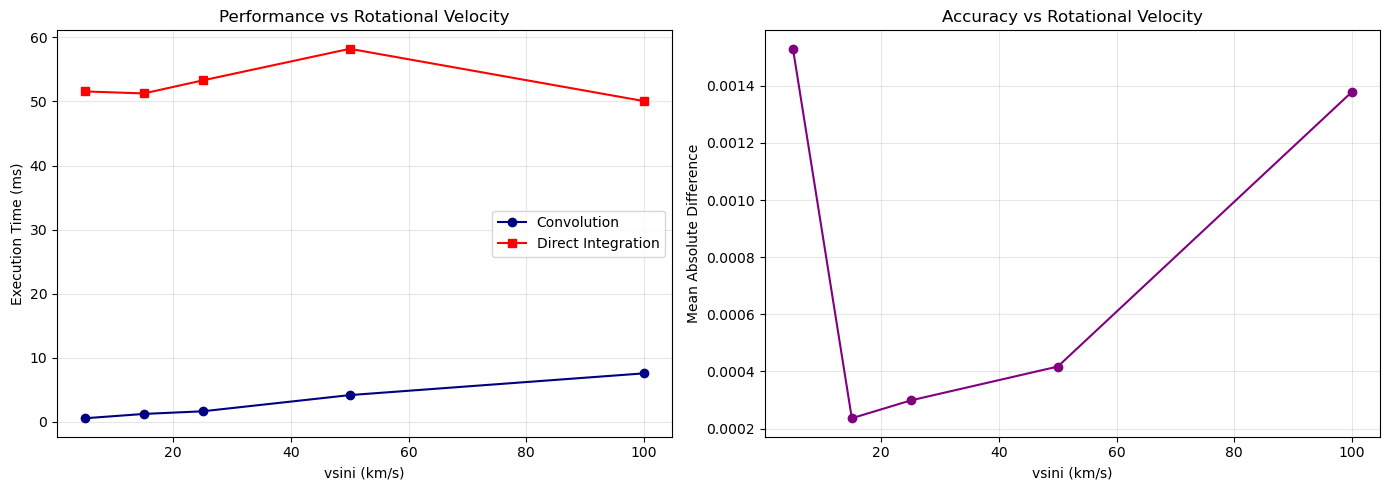

In [58]:
# Test with different vsini values to see how differences scale
vsini_test_values = [5, 15, 25, 50, 100]  # km/s
differences = []
conv_times_test = []
direct_times_test = []

print("Testing with different vsini values...")
print(f"{'vsini (km/s)':<12} {'Conv Time (ms)':<15} {'Direct Time (ms)':<16} {'Difference':<12}")
print("-" * 60)

for vsini_test in vsini_test_values:
    # Convolution method
    start_time = time.time()
    flux_conv_test = RB(vsini=vsini_test, epsilon=eps)
    conv_time_test = time.time() - start_time
    
    # Direct integration method (using moderate resolution for speed)
    start_time = time.time()
    flux_direct_test = RB.direct_integration_carvalho(vsini=vsini_test, eps=eps, nr=20, ntheta=100)
    direct_time_test = time.time() - start_time
    
    # Calculate difference
    diff = np.mean(np.abs(flux_direct_test - flux_conv_test))
    
    differences.append(diff)
    conv_times_test.append(conv_time_test)
    direct_times_test.append(direct_time_test)
    
    print(f"{vsini_test:<12} {conv_time_test*1000:<15.1f} {direct_time_test*1000:<16.1f} {diff:<12.2e}")

# Plot scaling behavior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(vsini_test_values, [t*1000 for t in conv_times_test], 'o-', label='Convolution', color='navy')
ax1.plot(vsini_test_values, [t*1000 for t in direct_times_test], 's-', label='Direct Integration', color='red')
ax1.set_xlabel('vsini (km/s)')
ax1.set_ylabel('Execution Time (ms)')
ax1.set_title('Performance vs Rotational Velocity')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(vsini_test_values, differences, 'o-', color='purple')
ax2.set_xlabel('vsini (km/s)')
ax2.set_ylabel('Mean Absolute Difference')
ax2.set_title('Accuracy vs Rotational Velocity')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Background: Direct Integration Method

### Overview

The direct integration method implemented in `direct_integration_carvalho()` uses a fundamentally different approach compared to the convolution-based method. Instead of creating a kernel and convolving it with the spectrum, this method directly integrates over the stellar disk to compute the rotationally broadened spectrum.

### Mathematical Foundation

The method divides the stellar disk into radial and azimuthal bins, then integrates the contribution from each element:

1. **Disk Discretization**: The stellar disk is divided into:
   - `nr` radial bins from center to limb
   - `ntheta` azimuthal bins in the largest radial annulus
   - Each radial annulus has `int(r * ntheta)` azimuthal bins

2. **Velocity Calculation**: For each disk element at position (r, θ):
   - **Solid body rotation**: `v = r * vsini * sin(θ)`
   - **Differential rotation**: `v = r * vsini * sin(θ) * (1 - dif/2 - (dif/2) * cos(2φ))`
   - Where φ is the stellar co-latitude

3. **Limb Darkening**: Each element is weighted by the limb darkening law:
   - `weight = (1 - ε + ε * cos(arcsin(r)))`
   - Where ε is the limb darkening coefficient

4. **Integration**: The final spectrum is computed as:
   ```
   S_broadened(λ) = Σ [area * weight * S(λ + λ*v/c)] / Σ [area * weight]
   ```

### Advantages of Direct Integration

1. **Physical Accuracy**: Directly models the physical process of stellar rotation
2. **Differential Rotation**: Can handle differential rotation (dif ≠ 0)
3. **Flexible Resolution**: Integration resolution can be adjusted for accuracy vs speed
4. **No Kernel Assumptions**: Doesn't rely on analytical kernel approximations

### When to Use Each Method

**Use Convolution Method when:**
- Speed is critical (10-100x faster)
- High accuracy is not required
- Working with large datasets
- Solid body rotation only

**Use Direct Integration Method when:**
- Maximum accuracy is needed
- Studying differential rotation
- Validating convolution results
- Research applications where physical fidelity matters

### Performance Considerations

The direct integration method scales as O(nr × ntheta × N), where N is the spectrum length, making it significantly slower than the O(N log N) convolution method. However, the integration resolution can be tuned to balance accuracy and speed.
